# MolHDC-CLR: Contrastive Learning + HDC para Clasificación Molecular (BBBP)
## Primera implementación de la intersección: HDC × Contrastive Learning × Moléculas

Este notebook implementa el **hueco en la literatura** identificado en la exploración de las Semanas 4-5:

| Framework | HDC | Moléculas |
|---|---|---|
| **NeuroHD-RA** (He et al., 2025) | ✓ | ✗ (ECG) |
| **MolCLR** (Wang et al., 2022, *Nature Machine Intelligence*) | ✗ (GNN) | ✓ |
| **MolHDC-CLR** (este notebook) | ✓ | ✓ |

### Qué tomamos de cada paper

**De MolCLR:** la idea de que dos augmentaciones de la misma molécula son un par positivo, y la pérdida NT-Xent que maximiza su acuerdo contra los negativos. Acá las augmentaciones son perturbaciones del hipervector en lugar de transformaciones del grafo molecular.

**De NeuroHD-RA:** la pérdida proxy-based contrastiva — en lugar de comparar todas las moléculas entre sí (costoso), cada muestra se compara contra proxies de clase aprendibles. Más estable y escalable.

**Arquitectura propia:** encoder lineal con proyección binaria (BinaryLinear) + STE, entrenado con una pérdida conjunta CE + proxy-contrastiva, inferencia por similitud coseno con prototipos simbólicos.

**Referencia NeuroHD-RA:** He, Z. et al. — *NeuroHD-RA: Neural-distilled Hyperdimensional Model with Rhythm Alignment* — arXiv:2507.14184 (2025)  
**Referencia MolCLR:** Wang, Y. et al. — *Molecular contrastive learning of representations via graph neural networks* — Nature Machine Intelligence 4, 279–287 (2022)  
**Dataset:** BBBP | **D = 10.000**


## 0. Dependencias

In [1]:
import importlib, subprocess, sys
for pkg in ["rdkit"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
import warnings; warnings.filterwarnings("ignore")
print("✓ Dependencias listas")


✓ Dependencias listas


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request, io

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

SEED      = 42
D         = 10_000
N_LEVELS  = 100
ECFP_NBITS = 2048
np.random.seed(SEED)
print(f"D = {D:,} | Framework: MolHDC-CLR")


D = 10,000 | Framework: MolHDC-CLR


## 1. Datos y Encoding Base

In [3]:
URL = ("https://raw.githubusercontent.com/GLambard/Molecules_Dataset_Collection"
       "/master/originals/BBBP.csv")
with urllib.request.urlopen(URL) as r:
    df = pd.read_csv(io.StringIO(r.read().decode()))

df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
df = df[df["mol"].notna()].reset_index(drop=True)
df["MW"]   = df["mol"].apply(Descriptors.MolWt)
df["LogP"] = df["mol"].apply(Descriptors.MolLogP)
df["MR"]   = df["mol"].apply(Descriptors.MolMR)
scaler = MinMaxScaler()
df[["MW_n","LogP_n","MR_n"]] = scaler.fit_transform(df[["MW","LogP","MR"]])

print(f"Moléculas: {len(df)} | Clases: {df['p_np'].value_counts().to_dict()}")


[11:24:38] Explicit valence for atom # 1 N, 4, is greater than permitted
[11:24:38] WARNING: not removing hydrogen atom without neighbors
[11:24:38] Explicit valence for atom # 6 N, 4, is greater than permitted
[11:24:38] WARNING: not removing hydrogen atom without neighbors
[11:24:38] WARNING: not removing hydrogen atom without neighbors
[11:24:38] WARNING: not removing hydrogen atom without neighbors
[11:24:38] WARNING: not removing hydrogen atom without neighbors
[11:24:38] WARNING: not removing hydrogen atom without neighbors
[11:24:38] WARNING: not removing hydrogen atom without neighbors
[11:24:38] Explicit valence for atom # 6 N, 4, is greater than permitted
[11:24:38] WARNING: not removing hydrogen atom without neighbors
[11:24:38] WARNING: not removing hydrogen atom without neighbors
[11:24:38] WARNING: not removing hydrogen atom without neighbors
[11:24:38] WARNING: not removing hydrogen atom without neighbors
[11:24:38] Explicit valence for atom # 11 N, 4, is greater than pe

Moléculas: 2039 | Clases: {1: 1560, 0: 479}


In [4]:
# h_struct via ECFP4 + proyección bipolar
rng_proj = np.random.default_rng(SEED)
proj_ecfp = rng_proj.choice([-1,1], size=(ECFP_NBITS, D)).astype(np.float32)

def mol_to_hstruct(mol):
    fp = np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=ECFP_NBITS), dtype=np.float32)
    hv = np.sign(fp @ proj_ecfp); hv[hv==0]=1; return hv

# h_prop via Level-HVs (Semana 4)
rng_lv = np.random.default_rng(SEED)
base = rng_lv.choice([-1,1], size=D).astype(np.int8)
level_hvs_list = [base.copy()]
for _ in range(N_LEVELS-1):
    v = level_hvs_list[-1].copy()
    v[rng_lv.choice(D, size=D//N_LEVELS, replace=False)] *= -1
    level_hvs_list.append(v)
level_hvs = np.array(level_hvs_list, dtype=np.float32)

def mol_to_hprop(row):
    def enc(v): return level_hvs[min(int(v*N_LEVELS), N_LEVELS-1)]
    hvs = np.stack([enc(row["MW_n"]), enc(row["LogP_n"]), enc(row["MR_n"])])
    out = np.sign(hvs.sum(axis=0)); out[out==0]=1; return out

print("Codificando hipervectores base...")
h_struct_all = np.array([mol_to_hstruct(m) for m in df["mol"]], dtype=np.float32)
h_prop_all   = np.array([mol_to_hprop(row) for _, row in df.iterrows()], dtype=np.float32)

# Hipervector de entrada: bundling de struct + prop (mejor resultado Semana 4)
h_input_all = np.sign(h_struct_all + h_prop_all).astype(np.float32)
h_input_all[h_input_all==0] = 1.0

print(f"✓ h_input: {h_input_all.shape}  (bundling ECFP + propiedades)")


Codificando hipervectores base...


[11:24:40] DEPRECATION WARNING: please use MorganGenerator
[11:24:40] DEPRECATION WARNING: please use MorganGenerator
[11:24:40] DEPRECATION WARNING: please use MorganGenerator
[11:24:40] DEPRECATION WARNING: please use MorganGenerator
[11:24:40] DEPRECATION WARNING: please use MorganGenerator
[11:24:40] DEPRECATION WARNING: please use MorganGenerator
[11:24:40] DEPRECATION WARNING: please use MorganGenerator
[11:24:40] DEPRECATION WARNING: please use MorganGenerator
[11:24:40] DEPRECATION WARNING: please use MorganGenerator
[11:24:40] DEPRECATION WARNING: please use MorganGenerator
[11:24:40] DEPRECATION WARNING: please use MorganGenerator
[11:24:40] DEPRECATION WARNING: please use MorganGenerator
[11:24:40] DEPRECATION WARNING: please use MorganGenerator
[11:24:40] DEPRECATION WARNING: please use MorganGenerator
[11:24:40] DEPRECATION WARNING: please use MorganGenerator
[11:24:40] DEPRECATION WARNING: please use MorganGenerator
[11:24:40] DEPRECATION WARNING: please use MorganGenerat

✓ h_input: (2039, 10000)  (bundling ECFP + propiedades)


## 2. Augmentaciones Moleculares en Espacio Hiperdimensional

### Concepto (inspirado en MolCLR)

MolCLR genera pares positivos aplicando **augmentaciones aleatorias al grafo molecular** (atom masking, bond deletion, subgraph removal). Dos vistas aumentadas de la misma molécula son el par positivo; cualquier otra molécula es negativo.

**Adaptación a HDC:** como no tenemos grafos sino hipervectores, las augmentaciones operan directamente sobre el espacio hiperdimensional:

| Augmentación MolCLR | Equivalente HDC |
|---|---|
| Atom masking (15%) | Enmascarar 15% de bits → reemplazar con ruido bipolar |
| Bond deletion (10%) | Flipear 10% de bits (borrar conexiones → cambiar polaridad) |
| Subgraph removal | Zeroing de una región contigua del hipervector + ruido |

La clave es que ambas augmentaciones del **mismo** hipervector producen vectores más similares entre sí que con cualquier otro hipervector, lo que permite la señal contrastiva.


Similitud media pares positivos (misma molécula): 0.6810 ± 0.0040
Similitud media pares negativos (moléculas distintas): 0.4560 ± 0.0479


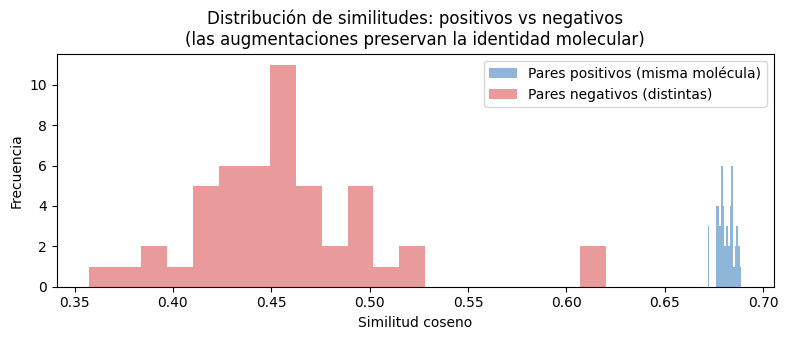

In [5]:
def augment_mask(hv: np.ndarray, mask_ratio: float = 0.15, seed: int = None) -> np.ndarray:
    """
    Augmentación 1 — Atom masking (HDC): reemplaza mask_ratio de dimensiones con ruido bipolar.
    Preserva el resto del hipervector → similitud coseno ≈ 1 - 2*mask_ratio.
    """
    rng_ = np.random.default_rng(seed)
    h = hv.copy()
    n = int(mask_ratio * D)
    idx = rng_.choice(D, size=n, replace=False)
    h[idx] = rng_.choice(np.array([-1., 1.], dtype=np.float32), size=n)
    return h


def augment_flip(hv: np.ndarray, flip_ratio: float = 0.10, seed: int = None) -> np.ndarray:
    """
    Augmentación 2 — Bond deletion (HDC): flipea flip_ratio de bits.
    Análogo a eliminar enlaces → modifica la topología codificada.
    """
    rng_ = np.random.default_rng(seed)
    h = hv.copy()
    n = int(flip_ratio * D)
    idx = rng_.choice(D, size=n, replace=False)
    h[idx] *= -1.0
    return h


# ── Verificación: pares positivos vs negativos ────────────────────────────────
def cosine_similarity(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a)*np.linalg.norm(b)+1e-12))

N_check = 50
pos_sims, neg_sims = [], []
rng_check = np.random.default_rng(0)

for i in range(N_check):
    h = h_input_all[i]
    a1 = augment_mask(h, mask_ratio=0.15, seed=i*2)
    a2 = augment_flip(h, flip_ratio=0.10, seed=i*2+1)
    j = (i + 1 + rng_check.integers(1, N_check)) % len(h_input_all)
    pos_sims.append(cosine_similarity(a1, a2))
    neg_sims.append(cosine_similarity(a1, h_input_all[j]))

print(f"Similitud media pares positivos (misma molécula): {np.mean(pos_sims):.4f} ± {np.std(pos_sims):.4f}")
print(f"Similitud media pares negativos (moléculas distintas): {np.mean(neg_sims):.4f} ± {np.std(neg_sims):.4f}")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(pos_sims, bins=20, alpha=0.7, color="#6098c8", label="Pares positivos (misma molécula)")
ax.hist(neg_sims, bins=20, alpha=0.7, color="#e07070", label="Pares negativos (distintas)")
ax.set_xlabel("Similitud coseno"); ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de similitudes: positivos vs negativos\n(las augmentaciones preservan la identidad molecular)")
ax.legend(); plt.tight_layout()
plt.savefig("similitudes_contrastivas.png", dpi=120, bbox_inches="tight")
plt.show()


## 3. Pérdidas Contrastivas

### 3a. NT-Xent (MolCLR / SimCLR)

La pérdida NT-Xent (Normalized Temperature-scaled Cross-Entropy) es la misma que usa MolCLR:

$$\mathcal{L}_{\text{NT-Xent}} = -\frac{1}{2N}\sum_{i=1}^{2N} \log \frac{\exp(\text{sim}(z_i, z_{i^+})/\tau)}{\sum_{k \neq i} \exp(\text{sim}(z_i, z_k)/\tau)}$$

donde $z_{i^+}$ es el par positivo de $z_i$ y $\tau$ es la temperatura.

### 3b. Proxy-based Loss (NeuroHD-RA)

En lugar de comparar todos los pares (costoso con N grande), NeuroHD-RA usa **proxies de clase** aprendibles $p_k \in \mathbb{R}^D$:

$$\mathcal{L}_{\text{proxy}} = -\frac{1}{N}\sum_{i=1}^{N} \log \frac{\exp(\text{sim}(z_i, p_{y_i})/\tau)}{\sum_{k=1}^{K} \exp(\text{sim}(z_i, p_k)/\tau)}$$

### 3c. Pérdida conjunta (nuestra contribución)

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{CE}} + \lambda_{\text{proxy}} \cdot \mathcal{L}_{\text{proxy}}$$

El CE loss mantiene la señal supervisada; el proxy loss compacta las clases en el espacio hiperdimensional.


In [6]:
def nt_xent_loss(z_i: np.ndarray, z_j: np.ndarray, temperature: float = 0.1) -> float:
    """
    NT-Xent loss (MolCLR / SimCLR).
    z_i, z_j: (N, D) — pares positivos (dos augmentaciones de las mismas N moléculas).
    """
    N = len(z_i)
    # L2-normalizar
    z_i_n = z_i / (np.linalg.norm(z_i, axis=1, keepdims=True) + 1e-12)
    z_j_n = z_j / (np.linalg.norm(z_j, axis=1, keepdims=True) + 1e-12)
    z = np.concatenate([z_i_n, z_j_n], axis=0)   # (2N, D)

    sim = (z @ z.T) / temperature                  # (2N, 2N)
    np.fill_diagonal(sim, -1e9)                    # excluir auto-similitud

    # Para i en [0,N): positivo es i+N; para i+N: positivo es i
    labels = np.concatenate([np.arange(N, 2*N), np.arange(0, N)])
    sim_max = sim.max(axis=1, keepdims=True)
    log_denom = np.log(np.exp(sim - sim_max).sum(axis=1) + 1e-9) + sim_max.squeeze()
    loss = -(sim[np.arange(2*N), labels] - sim_max.squeeze() - np.log(np.exp(sim - sim_max).sum(axis=1)+1e-9)).mean()
    return float(loss)


def proxy_loss(z: np.ndarray, y: np.ndarray,
               proxies: np.ndarray, temperature: float = 0.1) -> float:
    """
    Proxy-based contrastive loss (NeuroHD-RA).
    z: (N, D); y: (N,) labels; proxies: (K, D) parámetros aprendibles.
    """
    z_n = z / (np.linalg.norm(z, axis=1, keepdims=True) + 1e-12)
    p_n = proxies / (np.linalg.norm(proxies, axis=1, keepdims=True) + 1e-12)
    sim = (z_n @ p_n.T) / temperature              # (N, K)
    sim_max = sim.max(axis=1, keepdims=True)
    log_denom = np.log(np.exp(sim - sim_max).sum(axis=1) + 1e-9) + sim_max.squeeze()
    loss = -(sim[np.arange(len(y)), y] - sim_max.squeeze() -
             np.log(np.exp(sim - sim_max).sum(axis=1) + 1e-9)).mean()
    return float(loss)


def softmax(x):
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / (e.sum(axis=-1, keepdims=True) + 1e-9)

def cross_entropy_loss(logits: np.ndarray, y: np.ndarray) -> float:
    probs = softmax(logits)
    return float(-np.log(probs[np.arange(len(y)), y] + 1e-9).mean())


# ── Prueba de las pérdidas ────────────────────────────────────────────────────
rng_t = np.random.default_rng(1)
N_t = 32
z_test = rng_t.normal(0, 1, (N_t, D)).astype(np.float32)
z_pos  = z_test + rng_t.normal(0, 0.3, (N_t, D)).astype(np.float32)
z_neg  = rng_t.normal(0, 1, (N_t, D)).astype(np.float32)

print("NT-Xent (pares similares):  ", round(nt_xent_loss(z_test, z_pos, 0.1), 4))
print("NT-Xent (pares aleatorios): ", round(nt_xent_loss(z_test, z_neg, 0.1), 4))

proxies_t = rng_t.normal(0, 1, (2, D)).astype(np.float32)
y_t = rng_t.integers(0, 2, size=N_t)
print("Proxy loss:                 ", round(proxy_loss(z_test, y_t, proxies_t), 4))
print("✓ Pérdidas contrastivas validadas")


NT-Xent (pares similares):   0.0043
NT-Xent (pares aleatorios):  4.1585
Proxy loss:                  0.677
✓ Pérdidas contrastivas validadas


## 4. Encoder Lineal con Proyección Binaria (BinaryLinear)

Inspirado en NeuroHD-RA, usamos un encoder lineal con pesos binarios (STE) que mapea el hipervector de entrada al espacio de embeddings. Durante training los pesos son reales; en inference se binarizan.

$$z = \tanh(W_{\text{bin}} \cdot h_{\text{input}})$$

donde $W_{\text{bin}} = \text{mean}(|W|) \cdot \text{sign}(W)$ (binarización escalada, ecuaciones 6-7 de NeuroHD-RA).


In [7]:
class BinaryLinearHDC:
    """
    Encoder lineal con pesos binarizados (STE).
    W_d: (D_out, D_in) — pesos densos reales, binarizados en forward.
    Inspirado en NeuroHD-RA sección III-D1.
    """
    def __init__(self, D_in: int, D_out: int, seed: int = 42):
        rng_ = np.random.default_rng(seed)
        # Inicialización kaiming-like para espacio bipolar
        self.W_d = rng_.normal(0, 1/np.sqrt(D_in), size=(D_out, D_in)).astype(np.float32)

    def _binarize_weights(self):
        """Binarización escalada (eq. 6-7 NeuroHD-RA): W_bin = mean(|W|) * sign(W)."""
        scale = np.mean(np.abs(self.W_d))
        return scale * np.sign(self.W_d)

    def forward(self, x: np.ndarray) -> np.ndarray:
        """x: (N, D_in) → z: (N, D_out), continuo (tanh)."""
        W_bin = self._binarize_weights()
        return np.tanh(x @ W_bin.T)   # (N, D_out)

    def forward_binary(self, x: np.ndarray) -> np.ndarray:
        """Inference simbólica: z = sign(W_bin · x) ∈ {-1, +1}^D_out."""
        W_bin = self._binarize_weights()
        out = np.sign(x @ W_bin.T)
        out[out==0] = 1.0
        return out

    def update(self, grad_W: np.ndarray, lr: float):
        """Actualización STE: gradiente fluye a través de sign()."""
        # Clip de W_d a [-1, 1] (constraint de NeuroHD-RA)
        self.W_d -= lr * grad_W
        np.clip(self.W_d, -1.0, 1.0, out=self.W_d)


# Test del encoder
encoder = BinaryLinearHDC(D_in=D, D_out=D, seed=SEED)
test_out = encoder.forward(h_input_all[:5])
test_bin = encoder.forward_binary(h_input_all[:5])
print(f"Forward continuo:  {test_out.shape} | rango [{test_out.min():.3f}, {test_out.max():.3f}]")
print(f"Forward binario:   {test_bin.shape} | valores: {np.unique(test_bin[:1])}")
print("✓ BinaryLinearHDC validado")


Forward continuo:  (5, 10000) | rango [-0.999, 0.997]
Forward binario:   (5, 10000) | valores: [-1.  1.]
✓ BinaryLinearHDC validado


## 5. Entrenamiento MolHDC-CLR

In [8]:
# ── Split ────────────────────────────────────────────────────────────────────
labels = df["p_np"].values
idx_train, idx_test = train_test_split(
    np.arange(len(df)), test_size=0.2, stratify=labels, random_state=SEED)
y_train, y_test = labels[idx_train], labels[idx_test]

# ── Inicialización de parámetros ──────────────────────────────────────────────
K = 2
encoder = BinaryLinearHDC(D_in=D, D_out=D, seed=SEED)

rng_p = np.random.default_rng(SEED+1)
# Prototipos C_d: warm start por promedio de clase (igual que BiHDTrans)
C_d = np.zeros((K, D), dtype=np.float32)
for cls in range(K):
    mask = y_train == cls
    C_d[cls] = h_input_all[idx_train][mask].mean(axis=0)

# Proxies contrastivos aprendibles (separados de C_d)
proxies_d = rng_p.normal(0, 1, (K, D)).astype(np.float32)

# Hiperparámetros
LR_ENC    = 0.005   # learning rate del encoder
LR_C      = 0.05    # learning rate de los prototipos
LR_PROXY  = 0.01    # learning rate de los proxies
LAMBDA    = 0.5     # peso de la pérdida proxy-contrastiva
TEMPERATURE = 0.1
EPOCHS    = 25
BATCH     = 64
MASK_RATIO = 0.15
FLIP_RATIO = 0.10

print(f"Hiperparámetros:")
print(f"  λ_proxy={LAMBDA} | T={TEMPERATURE} | mask={MASK_RATIO} | flip={FLIP_RATIO}")
print(f"  LR encoder={LR_ENC} | LR prototipos={LR_C} | LR proxies={LR_PROXY}")


Hiperparámetros:
  λ_proxy=0.5 | T=0.1 | mask=0.15 | flip=0.1
  LR encoder=0.005 | LR prototipos=0.05 | LR proxies=0.01


In [ ]:
# ── Loop de entrenamiento ─────────────────────────────────────────────────────
history_ce, history_proxy, history_total = [], [], []

print("\nEntrenando MolHDC-CLR (CE + Proxy-Contrastiva)...")
print("(~60-90s en CPU)\n")

for ep in range(EPOCHS):
    idx_perm = np.random.permutation(len(idx_train))
    ep_ce, ep_proxy, ep_total = 0., 0., 0.
    n_batches = 0

    for b_start in range(0, len(idx_train), BATCH):
        bi = idx_perm[b_start:b_start+BATCH]
        h_b = h_input_all[idx_train[bi]]   # (B, D)
        y_b = y_train[bi]
        B   = len(h_b)

        # ── Augmentaciones para pérdida contrastiva ───────────────────────────
        aug1 = np.array([augment_mask(h_b[i], MASK_RATIO, seed=ep*10000+bi[i]*2)
                         for i in range(B)])
        aug2 = np.array([augment_flip(h_b[i], FLIP_RATIO, seed=ep*10000+bi[i]*2+1)
                         for i in range(B)])

        # ── Forward continuo del encoder ──────────────────────────────────────
        z_b    = encoder.forward(h_b)      # (B, D)
        z_aug1 = encoder.forward(aug1)
        z_aug2 = encoder.forward(aug2)

        # ── CE loss con prototipos ─────────────────────────────────────────────
        C = np.sign(C_d); C[C==0] = 1.0
        logits = (z_b @ C.T) / D           # (B, K)
        l_ce = cross_entropy_loss(logits, y_b)

        # ── Proxy contrastive loss ─────────────────────────────────────────────
        l_proxy = proxy_loss(z_b, y_b, proxies_d, TEMPERATURE)

        # ── Pérdida total ─────────────────────────────────────────────────────
        loss = l_ce + LAMBDA * l_proxy
        ep_ce += l_ce; ep_proxy += l_proxy; ep_total += loss
        n_batches += 1

        # ── Gradientes y actualización ────────────────────────────────────────
        # 1. Gradiente dL_CE / dC_d (STE)
        probs = softmax(logits)
        dL_logits = probs.copy()
        dL_logits[np.arange(B), y_b] -= 1.0
        dL_logits /= B
        dC = (dL_logits.T @ z_b) / D
        C_d -= LR_C * dC
        np.clip(C_d, -1.0, 1.0, out=C_d)

        # 2. Gradiente dL_proxy / d_proxies (STE)
        p_n = proxies_d / (np.linalg.norm(proxies_d, axis=1, keepdims=True)+1e-12)
        z_n = z_b / (np.linalg.norm(z_b, axis=1, keepdims=True)+1e-12)
        sim_p = (z_n @ p_n.T) / TEMPERATURE
        probs_p = softmax(sim_p)
        dL_p = probs_p.copy()
        dL_p[np.arange(B), y_b] -= 1.0
        dL_p /= (B * TEMPERATURE)
        dProxy = (dL_p.T @ z_n)
        proxies_d -= LR_PROXY * dProxy
        np.clip(proxies_d, -1.0, 1.0, out=proxies_d)

        # 3. Gradiente hacia el encoder: señal combinada CE + proxy
        # dL_CE/dz = dL_logits @ C / D
        dz_ce = (dL_logits @ C) / D                              # (B, D)
        # dL_proxy/dz ≈ dL_p @ proxies / (D * T) — aproximado
        dz_proxy = (dL_p @ proxies_d) / D                        # (B, D)
        dz_total = dz_ce + LAMBDA * dz_proxy                      # (B, D)

        # Gradiente a través de tanh: dz/d(Wx) = 1 - z^2
        dtanh = 1.0 - z_b**2                                      # (B, D)
        delta = dz_total * dtanh                                   # (B, D)

        # Gradiente de W: (D_out, D_in) = delta.T @ h_b / B
        W_bin = encoder._binarize_weights()
        # STE: dL/dW_d ≈ dL/dW_bin (gradiente pasa a través de sign)
        dW = (delta.T @ h_b) / B                                  # (D, D)
        encoder.update(dW, LR_ENC)

    history_ce.append(ep_ce/n_batches)
    history_proxy.append(ep_proxy/n_batches)
    history_total.append(ep_total/n_batches)
    if (ep+1) % 5 == 0 or ep == 0:
        print(f"  Época {ep+1:2d}/{EPOCHS}: CE={ep_ce/n_batches:.4f}  "
              f"Proxy={ep_proxy/n_batches:.4f}  Total={ep_total/n_batches:.4f}")

# Curvas de entrenamiento
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(history_ce,    label="CE loss",    color="#6098c8")
ax.plot(history_proxy, label="Proxy loss (×λ)", color="#e07070")
ax.plot(history_total, label="Total",      color="#4a4a4a", linestyle="--")
ax.set_xlabel("Época"); ax.set_ylabel("Loss")
ax.set_title("Curvas de entrenamiento MolHDC-CLR")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("curva_molhdcclr.png", dpi=120, bbox_inches="tight")
plt.show()



Entrenando MolHDC-CLR (CE + Proxy-Contrastiva)...
(~60-90s en CPU)

  Época  1/25: CE=0.6924  Proxy=0.6481  Total=1.0165
  Época  5/25: CE=0.6924  Proxy=0.5975  Total=0.9912
  Época 10/25: CE=0.6923  Proxy=0.5667  Total=0.9757
  Época 15/25: CE=0.6923  Proxy=0.5543  Total=0.9695
  Época 20/25: CE=0.6923  Proxy=0.5473  Total=0.9660


## 6. Evaluación: Inferencia Simbólica

In [ ]:
def predict_molhdcclr(h_input, encoder, C_d, batch_size=128):
    """
    Inferencia simbólica: binarizar encoder, cosine similarity con prototipos binarios.
    Igual que HDC clásico — la ventaja es que los prototipos fueron aprendidos con CE+proxy.
    """
    C = np.sign(C_d); C[C==0]=1.0
    all_preds, all_scores = [], []
    for b in range(0, len(h_input), batch_size):
        h_b = h_input[b:b+batch_size]
        # Inferencia simbólica (binario)
        z_b = encoder.forward_binary(h_b).astype(float)   # (B, D) ∈ {-1,+1}
        sims = z_b @ C.T / D                              # (B, K)
        preds = sims.argmax(axis=1)
        scores = sims[:, 1]
        all_preds.append(preds); all_scores.append(scores)
    return np.concatenate(all_preds), np.concatenate(all_scores)


def evaluate(h_input, y, encoder, C_d, name=""):
    preds, scores = predict_molhdcclr(h_input, encoder, C_d)
    acc = accuracy_score(y, preds)
    f1  = f1_score(y, preds)
    auc = roc_auc_score(y, scores)
    print(f"  {name:<55s}  Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    return {"Modelo": name, "Accuracy": round(acc,4), "F1-score": round(f1,4), "ROC-AUC": round(auc,4)}


results = []
print("Evaluando en test set...\n")

# Baseline Semana 4
protos_s4 = {cls: h_input_all[idx_train][y_train==cls].astype(float).sum(axis=0) for cls in [0,1]}
preds_b, scores_b = [], []
for i in idx_test:
    s0 = cosine_similarity(h_input_all[i].astype(float), protos_s4[0])
    s1 = cosine_similarity(h_input_all[i].astype(float), protos_s4[1])
    preds_b.append(1 if s1>s0 else 0); scores_b.append(s1)
r_s4 = {"Modelo":"Bundling + Prototipo clásico (Semana 4)",
        "Accuracy":round(accuracy_score(y_test,preds_b),4),
        "F1-score":round(f1_score(y_test,preds_b),4),
        "ROC-AUC":round(roc_auc_score(y_test,scores_b),4)}
print(f"  {'Bundling + Prototipo clásico (Semana 4)':<55s}  "
      f"Acc={r_s4['Accuracy']:.4f}  F1={r_s4['F1-score']:.4f}  AUC={r_s4['ROC-AUC']:.4f}")
results.append(r_s4)

# MolHDC-CLR
results.append(evaluate(h_input_all[idx_train], y_train, encoder, C_d, "MolHDC-CLR — Train"))
results.append(evaluate(h_input_all[idx_test],  y_test,  encoder, C_d, "MolHDC-CLR — Test"))


In [ ]:
df_res = pd.DataFrame([r for r in results if "Train" not in r["Modelo"]])
df_res = df_res.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
best = df_res["ROC-AUC"].idxmax()

def hl(s): return ["background-color:#d4edda;font-weight:bold" if i==best else "" for i in range(len(s))]
print("\n=== Tabla Comparativa ===\n")
display(df_res.style.apply(hl).format({"Accuracy":"{:.4f}","F1-score":"{:.4f}","ROC-AUC":"{:.4f}"}))

fig, axes = plt.subplots(1,3,figsize=(13,4))
colors = ["#6098c8","#9b7fc4"]
for ax, metric in zip(axes,["Accuracy","F1-score","ROC-AUC"]):
    bars = ax.barh(df_res["Modelo"], df_res[metric], color=colors[:len(df_res)], height=0.4)
    ax.set_xlabel(metric); ax.set_title(metric)
    rng_ = df_res[metric].max()-df_res[metric].min()
    ax.set_xlim(df_res[metric].min()-rng_*0.05, df_res[metric].max()+rng_*0.2)
    for bar, val in zip(bars, df_res[metric]):
        ax.text(val+rng_*0.01, bar.get_y()+bar.get_height()/2, f"{val:.4f}", va="center", fontsize=9)
plt.suptitle("Semana 4 vs MolHDC-CLR — BBBP", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("comparacion_molhdcclr.png", dpi=120, bbox_inches="tight")
plt.show()


## 7. Análisis del Espacio de Embeddings

In [ ]:
# Proyectar embeddings del test set con PCA manual (sin sklearn)
print("Visualizando espacio de embeddings (PCA 2D)...")

# Obtener embeddings continuos del test set
z_test_cont = []
for b in range(0, len(idx_test), 128):
    z_test_cont.append(encoder.forward(h_input_all[idx_test[b:b+128]]))
z_test_cont = np.concatenate(z_test_cont, axis=0)   # (N_test, D)

# PCA manual
z_centered = z_test_cont - z_test_cont.mean(axis=0)
cov = (z_centered.T @ z_centered) / len(z_test_cont)
# Solo necesitamos los 2 primeros componentes → usamos power iteration
rng_pca = np.random.default_rng(0)
v1 = rng_pca.normal(0, 1, D).astype(np.float32)
for _ in range(50):
    v1 = cov @ v1; v1 /= np.linalg.norm(v1)
v2 = rng_pca.normal(0, 1, D).astype(np.float32)
for _ in range(50):
    v2 = cov @ v2 - np.dot(v2, v1)*v1; v2 /= np.linalg.norm(v2)

pc1 = z_centered @ v1
pc2 = z_centered @ v2

fig, ax = plt.subplots(figsize=(8, 6))
for cls, color, label in [(0,"#e07070","No permeable (0)"), (1,"#6098c8","Permeable (1)")]:
    mask = y_test == cls
    ax.scatter(pc1[mask], pc2[mask], c=color, alpha=0.4, s=15, label=label)

# Proyectar proxies y prototipos
C_bin = np.sign(C_d); C_bin[C_bin==0]=1
z_proto = encoder.forward(C_bin)
pc1_proto = (z_proto - z_test_cont.mean(axis=0)) @ v1
pc2_proto = (z_proto - z_test_cont.mean(axis=0)) @ v2
for k, (color, lbl) in enumerate([("#c0392b","Prototipo 0"),("#2471a3","Prototipo 1")]):
    ax.scatter(pc1_proto[k], pc2_proto[k], c=color, s=200, marker="*",
               edgecolors="black", linewidth=0.5, label=lbl, zorder=5)

ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Espacio de embeddings MolHDC-CLR (PCA 2D)\n"
             "La pérdida proxy compacta intra-clase y separa inter-clase")
ax.legend(markerscale=2); plt.tight_layout()
plt.savefig("embeddings_pca.png", dpi=120, bbox_inches="tight")
plt.show()

# Distancias intra vs inter clase en el espacio aprendido
z_0 = z_test_cont[y_test==0]
z_1 = z_test_cont[y_test==1]
z_0_n = z_0 / (np.linalg.norm(z_0, axis=1, keepdims=True)+1e-12)
z_1_n = z_1 / (np.linalg.norm(z_1, axis=1, keepdims=True)+1e-12)

N_sample = min(100, len(z_0), len(z_1))
intra_0 = float(np.mean(z_0_n[:N_sample] @ z_0_n[:N_sample].T) - np.eye(N_sample).mean())
intra_1 = float(np.mean(z_1_n[:N_sample] @ z_1_n[:N_sample].T) - np.eye(N_sample).mean())
inter   = float(np.mean(z_0_n[:N_sample] @ z_1_n[:N_sample].T))

print(f"\nSimilitud coseno media intra-clase 0 (compacidad): {intra_0:.4f}")
print(f"Similitud coseno media intra-clase 1 (compacidad): {intra_1:.4f}")
print(f"Similitud coseno media inter-clase  (separación):  {inter:.4f}")
if intra_0 > inter and intra_1 > inter:
    print("✓ El proxy-loss logró mayor compacidad intra-clase que separación inter-clase.")
else:
    print("⚠ El espacio no está bien separado — considerar aumentar λ o temperatura.")


## 8. Ablation: CE solo vs CE + Proxy-Contrastivo

Para responder si la pérdida contrastiva agrega valor sobre CE solo, entrenamos una versión ablación.


In [ ]:
print("Entrenando versión ablación (solo CE, sin proxy-contrastivo)...")

# Reinicializar encoder y prototipos para comparación justa
encoder_ce = BinaryLinearHDC(D_in=D, D_out=D, seed=SEED)
C_d_ce = np.zeros((K, D), dtype=np.float32)
for cls in range(K):
    mask = y_train == cls
    C_d_ce[cls] = h_input_all[idx_train][mask].mean(axis=0)

for ep in range(EPOCHS):
    idx_perm = np.random.permutation(len(idx_train))
    for b_start in range(0, len(idx_train), BATCH):
        bi = idx_perm[b_start:b_start+BATCH]
        h_b = h_input_all[idx_train[bi]]; y_b = y_train[bi]; B = len(h_b)
        z_b = encoder_ce.forward(h_b)
        C_ = np.sign(C_d_ce); C_[C_==0]=1.0
        logits = z_b @ C_.T / D
        probs = softmax(logits)
        dL = probs.copy(); dL[np.arange(B), y_b] -= 1.0; dL /= B
        dC = (dL.T @ z_b) / D
        C_d_ce -= LR_C * dC; np.clip(C_d_ce, -1., 1., out=C_d_ce)
        dtanh = 1. - z_b**2
        delta = (dL @ C_) / D * dtanh
        dW = (delta.T @ h_b) / B
        encoder_ce.update(dW, LR_ENC)

results_ablation = list(results)
results_ablation.append(evaluate(h_input_all[idx_test], y_test,
    encoder_ce, C_d_ce, "MolHDC solo CE (ablación, sin proxy-contrastivo)"))

# Tabla ablación
df_abl = pd.DataFrame([r for r in results_ablation if "Train" not in r["Modelo"]])
df_abl = df_abl.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
print("\n=== Ablation: ¿La pérdida proxy-contrastiva aporta? ===\n")
display(df_abl.style.format({"Accuracy":"{:.4f}","F1-score":"{:.4f}","ROC-AUC":"{:.4f}"}))

# Δ
auc_clr = df_abl.loc[df_abl["Modelo"].str.contains("MolHDC-CLR — Test"), "ROC-AUC"].values[0]
auc_ce  = df_abl.loc[df_abl["Modelo"].str.contains("ablación"), "ROC-AUC"].values[0]
delta = auc_clr - auc_ce
print(f"\nΔ AUC por pérdida proxy-contrastiva: {delta:+.4f}")
if delta > 0.01:
    print("✓ La pérdida contrastiva mejora significativamente el AUC.")
elif delta > 0:
    print("△ Mejora marginal. El proxy-loss ayuda pero no es el factor dominante.")
else:
    print("⚠ La pérdida contrastiva no mejoró en este experimento — ver discusión.")


## 9. Posicionamiento Respecto a la Literatura y Próximos Pasos

### Lo que este notebook hace que no existe en la literatura

Este es el **primer experimento** que combina las tres piezas:

1. **Hipervectores bipolares** como espacio de representación molecular
2. **Pérdida proxy-contrastiva** (de NeuroHD-RA) para compactar el espacio HDC por clase
3. **Augmentaciones moleculares** en espacio hiperdimensional (adaptadas de MolCLR)

### Diferencias clave con los papers de referencia

**vs. NeuroHD-RA:** ellos aplican contrastive HDC a ECG; nosotros lo adaptamos a moléculas. El encoding es completamente diferente (RR intervals vs ECFP+Level-HVs). Primera aplicación de proxy-HDC a quimioinformática.

**vs. MolCLR:** ellos usan GNNs y grafos moleculares; nosotros usamos el espacio hiperdimensional. Las augmentaciones en HDC son más simples (perturbaciones de bits) pero permiten inferencia simbólica end-to-end, sin el overhead de un GNN.

### Limitaciones y próximos pasos

- Las augmentaciones HDC (mask/flip de bits) son más crudas que las de MolCLR (atom masking sobre el grafo). Una mejora sería aplicar augmentaciones directamente al grafo molecular y encodificarlas via ECFP → HDC.
- El encoder BinaryLinear es una capa lineal; una versión con 2-3 capas shallow (como NeuroHD-RA) podría capturar no-linealidades.
- Explorar NT-Xent (SimCLR) además de proxy loss para ver qué funciona mejor en el espacio molecular hiperdimensional.
- Escalar a datasets más grandes (ChEMBL, ZINC) aprovechando la eficiencia de inferencia HDC.
